In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")
schema = pd.read_sql("PRAGMA table_info(checker);", conn)

print(schema)

   cid       name       type  notnull dflt_value  pk
0    0      index    INTEGER        0       None   0
1    1     status       TEXT        0       None   0
2    2    success    INTEGER        0       None   0
3    3  timestamp  TIMESTAMP        0       None   0
4    4  numTrials    INTEGER        0       None   0
5    5    labname       TEXT        0       None   0
6    6        uid       TEXT        0       None   0


In [3]:
query = pd.read_sql("""
                WITH views AS (
                     SELECT DATE(datetime) AS date,
                            COUNT(datetime) AS views
                     FROM pageviews
                     WHERE uid LIKE 'user_%'
                     GROUP BY DATE(datetime)
                     ),
                     commits AS (
                     SELECT DATE(timestamp) AS date,
                            COUNT(timestamp) AS commits
                     FROM checker
                     WHERE uid LIKE 'user_%'
                     GROUP BY DATE(timestamp))
                SELECT v.date, v.views, c.commits
                FROM views v
                JOIN commits c ON v.date = c.date
""", conn)

In [4]:
print(query.shape)
query.head()

(32, 3)


,date,views,commits
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28


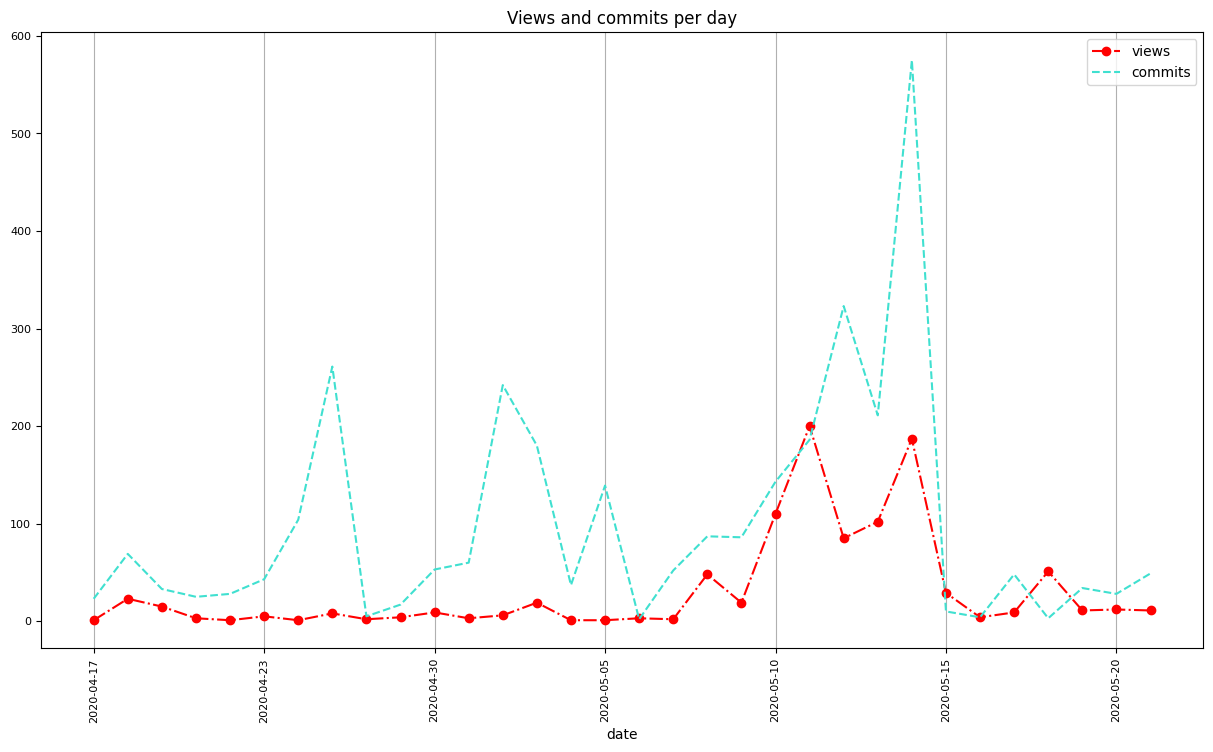

In [5]:
ax = query.plot(x='date', y='views',
                 linestyle='dashdot',
                 marker='o',
                 color='red',
                 figsize=(15, 8),
                 fontsize=8,
                 title='Views and commits per day')

query.plot(x='date', y='commits',
            linestyle='dashed',
            color='#40E0D0',
            ax=ax)

ax.grid(axis='x')
ax.tick_params(axis="x", rotation=90)

In [6]:
conn.close()

How many times was the number of views larger than 150? The answer is 2 times.